<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Transformer_V/self_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
input = torch.tensor(
    [
        [0.72, 0.45, 0.31],  # Dream    (x^1)
        [0.75, 0.20, 0.55],  # big      (x^2)
        [0.30, 0.80, 0.40],  # and      (x^3)
        [0.85, 0.35, 0.60],  # work     (x^4)
        [0.55, 0.15, 0.75],  # for      (x^5)
        [0.25, 0.20, 0.85],  # it       (x^6)
    ]
)

# Corresponding words
words = ["Dream", "big", "and", "work", "for", "it"]

In [ ]:
from ast import MatchSingleton
magnitudes = torch.norm(input, dim=1)

# Print the magnitudes
print("Magnitudes of the vectors:")
print(magnitudes)
for word , magnitudes in zip(words, magnitudes):
  print(f"{word} : {magnitudes.item():.4f}")

Magnitudes of the vectors:
tensor([0.9039, 0.9513, 0.9434, 1.0977, 0.9421, 0.9083])
Dream : 0.9039
big : 0.9513
and : 0.9434
work : 1.0977
for : 0.9421
it : 0.9083


In [ ]:

x_coords = input[:,0].numpy()
y_coords = input[:,1].numpy()
z_coords = input[:,2].numpy()
x_coords

array([0.72, 0.75, 0.3 , 0.85, 0.55, 0.25], dtype=float32)

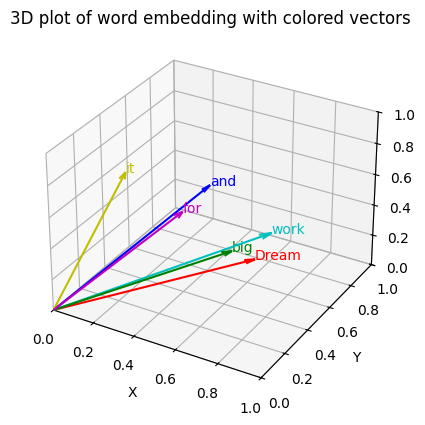

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_coords = input[:,0].numpy()
y_coords = input[:,1].numpy()
z_coords = input[:,2].numpy()

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for x, y, z, word, color in zip(x_coords, y_coords, z_coords, words, colors):
  ax.quiver(0,0,0,x,y,z, color=color, arrow_length_ratio=0.05)
  ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])
plt.title('3D plot of word embedding with colored vectors')
plt.show()

In [ ]:
query = input[1]
query

tensor([0.7500, 0.2000, 0.5500])

In [ ]:
query = input[1]

attn_score_2 = torch.empty(input.shape[0])
for i, x_i in enumerate(input):
  # print('x_i=', x_i)
  # print('query=', query)
  attn_score_2[i] = torch.dot(x_i, query)

print(attn_score_2)


tensor([0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950])


In [ ]:
# attn_weight_2_tmp = attn_score_2 / attn_score_2.sum()

# print("attention weight:", attn_weight_2_tmp)
# print('sum:', attn_weight_2_tmp.sum())

attention weight: tensor([0.1634, 0.1848, 0.1235, 0.2118, 0.1746, 0.1419])
sum: tensor(1.0000)


In [ ]:
import tensorflow as tf

attn_score_2_tf = tf.convert_to_tensor(attn_score_2.numpy())

attn_weights_2_temp = tf.nn.softmax(attn_score_2_tf)

print('attention weight :', attn_weights_2_temp.numpy())
print('sum:', attn_weights_2_temp.numpy().sum())

attention weight : [0.16244562 0.18033989 0.13359906 0.20589025 0.1715446  0.14618066]
sum: 1.0000001


In [ ]:
attn_score = input @ input.T

print(attn_score)

tensor([[0.8170, 0.8005, 0.7000, 0.9555, 0.6960, 0.5335],
        [0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950],
        [0.7000, 0.6050, 0.8900, 0.7750, 0.5850, 0.5750],
        [0.9555, 1.0375, 0.7750, 1.2050, 0.9700, 0.7925],
        [0.6960, 0.8550, 0.5850, 0.9700, 0.8875, 0.8050],
        [0.5335, 0.6950, 0.5750, 0.7925, 0.8050, 0.8250]])


In [ ]:
attn_weight = torch.softmax(attn_score, dim=1)
print(attn_weight)

tensor([[0.1766, 0.1738, 0.1571, 0.2029, 0.1565, 0.1330],
        [0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462],
        [0.1675, 0.1523, 0.2025, 0.1805, 0.1493, 0.1478],
        [0.1648, 0.1789, 0.1376, 0.2115, 0.1672, 0.1400],
        [0.1491, 0.1747, 0.1334, 0.1960, 0.1805, 0.1662],
        [0.1396, 0.1641, 0.1455, 0.1809, 0.1831, 0.1868]])


In [ ]:
row2_sum = sum([0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462])

print("row 2 sum:", row2_sum)
print("all row sums:", attn_weight.sum(dim=-1))

row 2 sum: 0.9999
all row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [ ]:
all_context_vecs = attn_weight @ input
print(all_context_vecs)

tensor([[0.5965, 0.3611, 0.5654],
        [0.5982, 0.3431, 0.5794],
        [0.5681, 0.3830, 0.5627],
        [0.6008, 0.3471, 0.5758],
        [0.5859, 0.3377, 0.5900],
        [0.5684, 0.3402, 0.5964]])


In [ ]:
input

tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.2000, 0.5500],
        [0.3000, 0.8000, 0.4000],
        [0.8500, 0.3500, 0.6000],
        [0.5500, 0.1500, 0.7500],
        [0.2500, 0.2000, 0.8500]])

In [ ]:
context_vec_2 = all_context_vecs[1]
print("previous 2nd context vector:", context_vec_2)

previous 2nd context vector: tensor([0.5982, 0.3431, 0.5794])


In [ ]:
input = torch.cat((input, context_vec_2.unsqueeze(0)), dim=0)

words.append('context vector')
print('updated inputs tensors:')
print(input)
print(words)


updated inputs tensors:
tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.2000, 0.5500],
        [0.3000, 0.8000, 0.4000],
        [0.8500, 0.3500, 0.6000],
        [0.5500, 0.1500, 0.7500],
        [0.2500, 0.2000, 0.8500],
        [0.5982, 0.3431, 0.5794]])
['Dream', 'big', 'and', 'work', 'for', 'it', 'context vector']


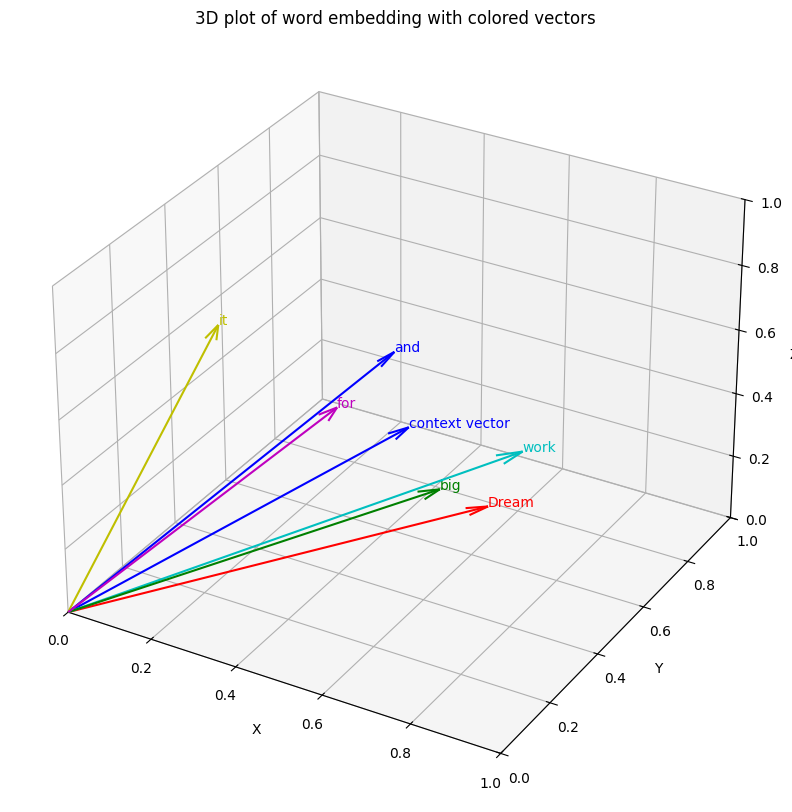

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_coords = input[:,0].numpy()
y_coords = input[:,1].numpy()
z_coords = input[:,2].numpy()

fig = plt.figure(figsize=(15, 10))

ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'b']

for x, y, z, word, color in zip(x_coords, y_coords, z_coords, words, colors):
  ax.quiver(0,0,0,x,y,z, color=color, arrow_length_ratio=0.05)
  ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])
plt.title('3D plot of word embedding with colored vectors')
plt.show()

# 37

In [3]:
import torch

input = torch.tensor([
    [0.72, 0.45, 0.31],  # Dream    (x^1)
    [0.75, 0.20, 0.55],  # big      (x^2)
    [0.30, 0.80, 0.40],  # and      (x^3)
    [0.85, 0.35, 0.60],  # work     (x^4)
    [0.55, 0.15, 0.75],  # for      (x^5)
    [0.25, 0.20, 0.85]   # it       (x^6)
])

# Corresponding words
words = ['Dream', 'big', 'and', 'work', 'for', 'it']

In [4]:
x_2 = input[1]
d_in = input.shape[1]
d_out = 2
print(x_2)

tensor([0.7500, 0.2000, 0.5500])


In [5]:
torch.manual_seed(123)
w_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
w_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
w_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)


In [6]:
print(w_key)

Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])


In [8]:
query2 = x_2 @ w_query
key2 = x_2 @ w_key
value2 = x_2 @ w_value

print(query2)
print(key2)
print(value2)

tensor([0.3131, 1.0017])
tensor([0.3126, 0.6001])
tensor([0.1852, 0.6829])


In [12]:
keys = input @ w_key
values = input @ w_value
querys = input @ w_query



print(keys.shape)
print(values.shape)
print(querys.shape)


print(keys)
print(values)
print(querys)

torch.Size([6, 2])
torch.Size([6, 2])
torch.Size([6, 2])
tensor([[0.2789, 0.6137],
        [0.3126, 0.6001],
        [0.3143, 0.8867],
        [0.3697, 0.7536],
        [0.3392, 0.6807],
        [0.3389, 0.7549]])
tensor([[0.2336, 0.5789],
        [0.1852, 0.6829],
        [0.3232, 0.7113],
        [0.2462, 0.8042],
        [0.1780, 0.7890],
        [0.1830, 0.8328]])
tensor([[0.3494, 0.9504],
        [0.3131, 1.0017],
        [0.3198, 1.0524],
        [0.3842, 1.2000],
        [0.2561, 1.0373],
        [0.1872, 1.0034]])


In [14]:
# key2 = keys[1]
# key2

In [16]:
key2 = keys[1]
attention_score = query2.dot(key2)
print(attention_score)

tensor(0.6990)


In [17]:
attention_score2 = query2 @ keys.T
print(attention_score2)

tensor([0.7021, 0.6990, 0.9867, 0.8707, 0.7880, 0.8624])


# attention weight

In [18]:
attention_score = querys @ keys.T
print(attention_score)

tensor([[0.6807, 0.6795, 0.9526, 0.8454, 0.7654, 0.8359],
        [0.7021, 0.6990, 0.9867, 0.8707, 0.7880, 0.8624],
        [0.7350, 0.7315, 1.0337, 0.9113, 0.8248, 0.9029],
        [0.8436, 0.8402, 1.1848, 1.0464, 0.9471, 1.0361],
        [0.7080, 0.7025, 1.0003, 0.8764, 0.7929, 0.8699],
        [0.6680, 0.6606, 0.9486, 0.8254, 0.7465, 0.8210]])


In [35]:
attn_score_2 = query2 @ keys.T
print(attention_score2)
d_k = keys.shape[-1]
attn_weight_2 = torch.softmax(attn_score_2 / (d_k ** 0.5), dim=-1)
print(attn_weight_2)
print(d_k)

tensor([0.7021, 0.6990, 0.9867, 0.8707, 0.7880, 0.8624])
tensor([0.1531, 0.1528, 0.1873, 0.1725, 0.1627, 0.1715])
2


# attn_weight

In [36]:
attention_score_all = querys @ keys.T
attn_weight_all = torch.softmax(attention_score_all / (d_k ** 0.5), dim=1)
print(attn_weight_all)

tensor([[0.1536, 0.1534, 0.1861, 0.1725, 0.1630, 0.1714],
        [0.1531, 0.1528, 0.1873, 0.1725, 0.1627, 0.1715],
        [0.1525, 0.1521, 0.1884, 0.1728, 0.1625, 0.1717],
        [0.1505, 0.1501, 0.1915, 0.1737, 0.1619, 0.1724],
        [0.1530, 0.1524, 0.1881, 0.1724, 0.1625, 0.1716],
        [0.1538, 0.1530, 0.1875, 0.1719, 0.1625, 0.1713]])


In [37]:
values

tensor([[0.2336, 0.5789],
        [0.1852, 0.6829],
        [0.3232, 0.7113],
        [0.2462, 0.8042],
        [0.1780, 0.7890],
        [0.1830, 0.8328]])

In [38]:
context_vec_2 = attn_weight_2 @ values
print(context_vec_2)

tensor([0.2274, 0.7362])


In [39]:
context_vec_all = attn_weight_all @ values
print(context_vec_all)

tensor([[0.2273, 0.7361],
        [0.2274, 0.7362],
        [0.2276, 0.7363],
        [0.2280, 0.7368],
        [0.2275, 0.7362],
        [0.2275, 0.7360]])


# hole thing in python class

In [40]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        attn_scores = queries @ keys.T  # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec